In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
mapname:  conversion of  failed


In [ ]:
zip_path = '/content/drive/MyDrive/RealWaste.zip'
extract_path = '/content/drive/MyDrive/RealWaste'
!unzip -q -o "{zip_path}" -d "{extract_path}"

mapname:  conversion of  failed


In [ ]:
extracted_folders = os.listdir(extract_path)
print(extracted_folders)

data_path = extract_path

Checking extracted folders inside: /content/drive/MyDrive/RealWaste
['4-Metal', '3-Glass', '6-Paper', '7-Plastic', '1-Cardboard', '9-Vegetation', '2-Food Organics', '8-Textile Trash', '5-Miscellaneous Trash']


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0, VGG16
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
data_path
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 5
EPOCHS = 100

In [ ]:
def split_data(data_path, train_split=0.8, val_split=0.2):
    data_gen = ImageDataGenerator(rescale=1.0/255.0, validation_split=val_split)

    train_data = data_gen.flow_from_directory(
        data_path,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        subset='training',
        class_mode='categorical'
    )

    val_data = data_gen.flow_from_directory(
        data_path,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        subset='validation',
        class_mode='categorical'
    )

    return train_data, val_data

In [ ]:
def tran_model(base_model, num_classes):
    for layer in base_model.layers:
        layer.trainable = False  

    x = base_model.output
    x = Flatten()(x)
    x = Dense(1024, activation='relu', kernel_regularizer='l2')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [ ]:
def mod_auc(model, train_data, val_data, epochs=EPOCHS):
    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=[early_stopping, reduce_lr]
    )

    plot_train(history)
    return history

In [ ]:
def plot_train(history):

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


def model_eval(model, test_data):
    test_data.reset()
    predictions = model.predict(test_data)
    predicted_classes = np.argmax(predictions, axis=-1)
    true_classes = test_data.classes
    class_labels = list(test_data.class_indices.keys())

    if len(class_labels) == 2:  
        auc_score = roc_auc_score(true_classes, predictions[:, 1])
    else:  
        auc_score = roc_auc_score(
            tf.keras.utils.to_categorical(true_classes, len(class_labels)),
            predictions,
            multi_class='ovr'
        )
    print(f"Final AUC Score: {auc_score:.4f}")

    print("Confusion Matrix:")
    print(confusion_matrix(true_classes, predicted_classes))

    print("\nClassification Report:")
    print(classification_report(true_classes, predicted_classes, target_names=class_labels))


Found 3803 images belonging to 9 classes.
Found 949 images belonging to 9 classes.
Training model: ResNet50
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


761/761 ━━━━━━━━━━━━━━━━━━━━ 71s 78ms/step - accuracy: 0.3025 - auc: 0.7179 - loss: 4.4573 - val_accuracy: 0.1739 - val_auc: 0.5697 - val_loss: 9.1743 - learning_rate: 0.0010
Epoch 2/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.3472 - auc: 0.7687 - loss: 2.9577 - val_accuracy: 0.1939 - val_auc: 0.5466 - val_loss: 30.2671 - learning_rate: 0.0010
Epoch 3/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.3703 - auc: 0.7906 - loss: 2.7384 - val_accuracy: 0.1054 - val_auc: 0.4968 - val_loss: 39.9789 - learning_rate: 0.0010
Epoch 4/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.3661 - auc: 0.7899 - loss: 3.0519 - val_accuracy: 0.1033 - val_auc: 0.5701 - val_loss: 8.4699 - learning_rate: 0.0010
Epoch 5/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.3639 - auc: 0.7863 - loss: 2.8233 - val_accuracy: 0.0864 - val_auc: 0.4865 - val_loss: 152.3651 - learning_rate: 0.0010
Epoch 6/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.3511

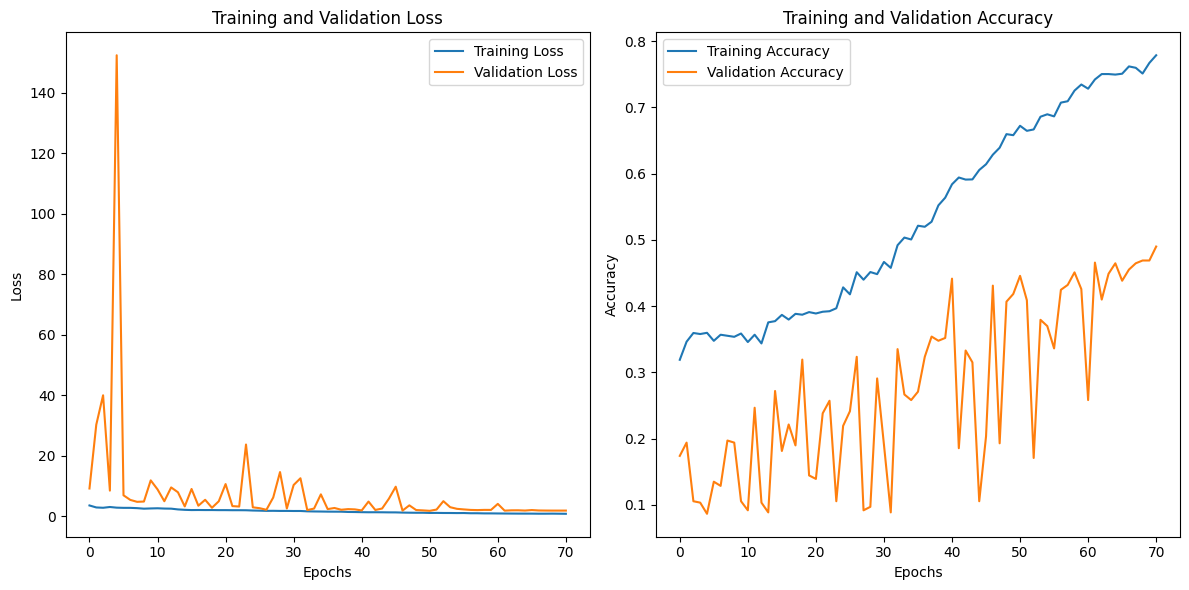

Evaluating ResNet50 on validation data
190/190 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step
Final AUC Score: 0.4973
Confusion Matrix:
[[ 9  4 19 17  7  6 19  2  9]
 [ 5  1  8 20 16  8 13  4  7]
 [ 9  5 10 11 13 12 19  0  5]
 [16  7 19 28 19 19 33  4 13]
 [10  3 15 18 11  5 27  0 10]
 [14  5 11 15  7 12 21  2 13]
 [14 12 26 35 20 19 41  3 14]
 [ 9  3 12  7  8  5 10  3  6]
 [ 7  4 13 17 15 10 11  0 10]]

Classification Report:
                       precision    recall  f1-score   support

          1-Cardboard       0.10      0.10      0.10        92
      2-Food Organics       0.02      0.01      0.02        82
              3-Glass       0.08      0.12      0.09        84
              4-Metal       0.17      0.18      0.17       158
5-Miscellaneous Trash       0.09      0.11      0.10        99
              6-Paper       0.12      0.12      0.12       100
            7-Plastic       0.21      0.22      0.22       184
      8-Textile Trash       0.17      0.05      0.07        63
         9-Ve

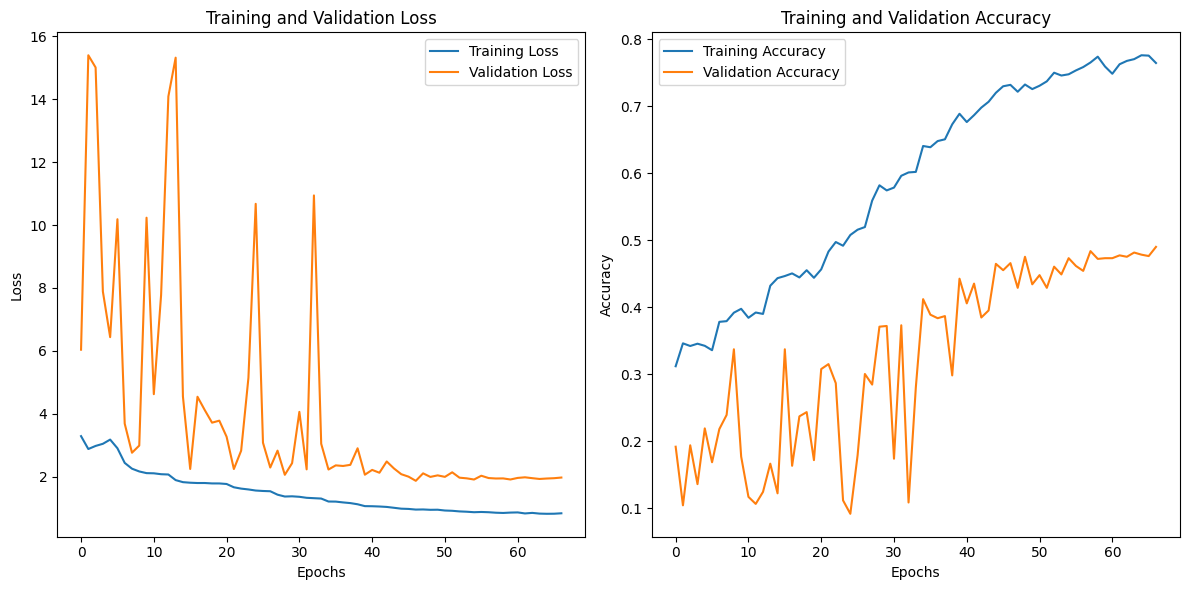

Evaluating ResNet101 on validation data
190/190 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step
Final AUC Score: 0.5020
Confusion Matrix:
[[18  5 11  9  6 11 17  3 12]
 [ 9  4  3 12  1 13 26  4 10]
 [14  1  8 12  2  9 17 10 11]
 [18  9 11 31  6 15 40 11 17]
 [14  5 10 18  6  7 23  4 12]
 [11  7  9 23  3 10 20  8  9]
 [16 16 11 33 12 17 26 24 29]
 [ 6  5  4 10  4 10 17  2  5]
 [ 8  2 13 12  5  7 19  8 13]]

Classification Report:
                       precision    recall  f1-score   support

          1-Cardboard       0.16      0.20      0.17        92
      2-Food Organics       0.07      0.05      0.06        82
              3-Glass       0.10      0.10      0.10        84
              4-Metal       0.19      0.20      0.19       158
5-Miscellaneous Trash       0.13      0.06      0.08        99
              6-Paper       0.10      0.10      0.10       100
            7-Plastic       0.13      0.14      0.13       184
      8-Textile Trash       0.03      0.03      0.03        63
         9-V

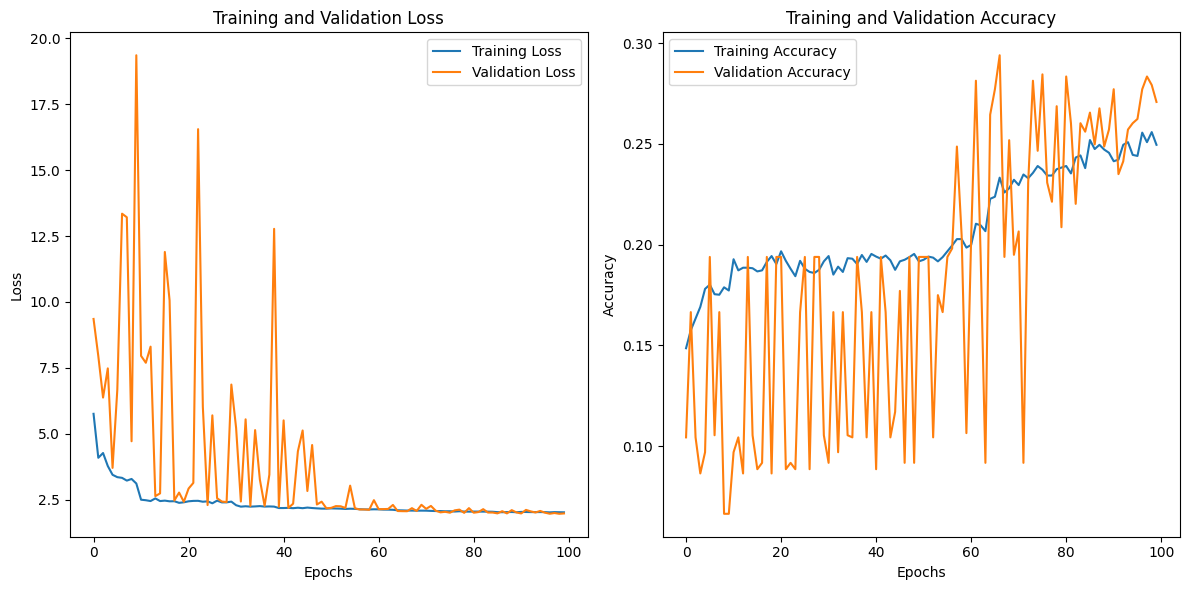

Evaluating EfficientNetB0 on validation data
190/190 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step
Final AUC Score: 0.5019
Confusion Matrix:
[[  0   0   0   0   0   0  82   0  10]
 [  0   0   0   0   0   0  72   0  10]
 [  0   0   0   0   0   0  80   0   4]
 [  0   0   0   0   0   0 145   0  13]
 [  0   0   0   0   0   0  86   0  13]
 [  0   0   0   0   0   0  88   0  12]
 [  0   0   0   0   0   0 161   0  23]
 [  0   0   0   0   0   0  53   0  10]
 [  0   0   0   0   0   0  76   0  11]]

Classification Report:
                       precision    recall  f1-score   support

          1-Cardboard       0.00      0.00      0.00        92
      2-Food Organics       0.00      0.00      0.00        82
              3-Glass       0.00      0.00      0.00        84
              4-Metal       0.00      0.00      0.00       158
5-Miscellaneous Trash       0.00      0.00      0.00        99
              6-Paper       0.00      0.00      0.00       100
            7-Plastic       0.19      0.88      0.31

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


761/761 ━━━━━━━━━━━━━━━━━━━━ 56s 64ms/step - accuracy: 0.4672 - auc: 0.8280 - loss: 7.4130 - val_accuracy: 0.3909 - val_auc: 0.7832 - val_loss: 4.4743 - learning_rate: 0.0010
Epoch 2/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.5735 - auc: 0.9027 - loss: 2.8984 - val_accuracy: 0.4067 - val_auc: 0.7904 - val_loss: 3.4115 - learning_rate: 0.0010
Epoch 3/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.5683 - auc: 0.9032 - loss: 2.5752 - val_accuracy: 0.3224 - val_auc: 0.7677 - val_loss: 3.8818 - learning_rate: 0.0010
Epoch 4/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.5741 - auc: 0.9044 - loss: 2.5542 - val_accuracy: 0.2403 - val_auc: 0.6418 - val_loss: 5.9019 - learning_rate: 0.0010
Epoch 5/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.5933 - auc: 0.9106 - loss: 2.4383 - val_accuracy: 0.2898 - val_auc: 0.6938 - val_loss: 5.0839 - learning_rate: 0.0010
Epoch 6/100
761/761 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.5832 - a

In [ ]:
if __name__ == "__main__":
    train_data, val_data = split_data(data_path)

    base_models = {
        "ResNet50": ResNet50(weights="imagenet", include_top=False, input_shape=(*IMAGE_SIZE, 3)),
        "ResNet101": ResNet101(weights="imagenet", include_top=False, input_shape=(*IMAGE_SIZE, 3)),
        "EfficientNetB0": EfficientNetB0(weights="imagenet", include_top=False, input_shape=(*IMAGE_SIZE, 3)),
        "VGG16": VGG16(weights="imagenet", include_top=False, input_shape=(*IMAGE_SIZE, 3))
    }

    for model_name, base_model in base_models.items():
        print(f"Training model: {model_name}")

        model = tran_model(base_model, num_classes=train_data.num_classes)

        history = mod_auc(model, train_data, val_data)
        
        print(f"Evaluating {model_name} on validation data")
        model_eval(model, val_data)